# NFL Playoff Contention - Schedule Optimization Effect (2021)

## Setup

This notebook measures whether an algorithmically optimized NFL schedule produces more teams in playoff contention deeper into the season compared to the historical baseline.

**Bayesian U-matrix:** The companion notebook `bayesian_hierarchical_season_simulator.ipynb` fits a hierarchical logistic regression on NFL regular-season results (2010–2024) and simulates 500 complete 2021 seasons. Each draw samples a team-season random effect from the posterior of $\sigma_{e_{tk}}$, producing game-by-game outcomes that capture within-season performance variance. The result is a 272×500 matrix `U_2021.csv`, where each cell is 0 (home won) or 1 (away won) for the corresponding matchup and draw.

**Schedule optimization:** The optimized 2021 schedule (`Schedule_2021_1.csv`) was produced by a two-stage stochastic program that maximizes expected playoff parity. The optimization methodology is proprietary and not reproduced here; the schedule is treated as a fixed input. 

* > We are however making publically available a Mixed Integer Program formulation for playoff contention, which is imported from lp_solver.py in the repo

**What we test:** Run each of the 500 Bayesian season draws through the elimination LP week by week, using the optimized schedule to determine which games occur in which week. Count how many teams remain in playoff contention at each of the final 7 weeks of the season. Compare the mean contention curve against the 2010–2024 historical mean from Notebook: **playoff_contention_historical.ipynb**.

## Data

In [ ]:
import sys; sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

from utils import team_convert, load_canonical_matchups, parse_optimized_schedule_csv
from lp_solver import (
    elimination_lp, ALL_DIVISIONS, DIVISION_CONFERENCES, AFC, NFC
)

load_dotenv(r'...\nfl_data_pipeline\.env')
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
print("DB connected")

DB connected


In [3]:
# --- Load U-matrix and matchup labels from Bayesian notebook output ------
U = np.loadtxt('../U_2021.csv', delimiter=',').astype(int)  # shape (272, 100)
labels = open('../matchup_labels_2021.txt').read().splitlines()
print(f"U-matrix shape: {U.shape}  ({U.shape[0]} matchups × {U.shape[1]} draws)")
print(f"Sample labels: {labels[:3]}")

U-matrix shape: (272, 100)  (272 matchups × 100 draws)
Sample labels: ['DAL @ TB', 'CHI @ LAR', 'MIA @ NE']


In [7]:
# --- Parse labels into (away_abbr, home_abbr) using team_convert ---------
# Bayesian notebook stores full team names (e.g. "New England Patriots @ Kansas City Chiefs")
u_matchups = []
for label in labels:
    parts = label.split(' @ ')
    away_name = parts[0].strip()
    home_name = parts[1].strip()
    try:
        away_abbr = team_convert(away_name, 'abbreviation')
        home_abbr = team_convert(home_name, 'abbreviation')
    except ValueError:
        # Already abbreviations (if notebook stored abbrs)
        away_abbr, home_abbr = away_name, home_name
    u_matchups.append((away_abbr, home_abbr))

print(f"Parsed {len(u_matchups)} matchup labels")
print(f"Sample: {u_matchups[:3]}")

Parsed 272 matchup labels
Sample: [('DAL', 'TB'), ('CHI', 'LAR'), ('MIA', 'NE')]


In [8]:
# --- Load canonical 2021 matchups from SQL --------------------------------
canonical = load_canonical_matchups(engine, 2021)  # 272 matchups
print(f"Canonical matchups: {len(canonical)}")

# --- Reorder U rows to align with canonical matchup order -----------------
u_lookup = {pair: i for i, pair in enumerate(u_matchups)}
reorder_idx = []
missing = []
for pair in canonical:
    if pair in u_lookup:
        reorder_idx.append(u_lookup[pair])
    else:
        missing.append(pair)

if missing:
    print(f"WARNING: {len(missing)} canonical matchups not found in U-matrix labels: {missing[:5]}")
else:
    U_ordered = U[reorder_idx, :]  # rows now align with canonical matchups
    print(f"U_ordered shape: {U_ordered.shape} — rows aligned with canonical matchups")

Canonical matchups: 272
U_ordered shape: (272, 100) — rows aligned with canonical matchups


In [9]:
canonical

[('DAL', 'TB'),
 ('PHI', 'ATL'),
 ('PIT', 'BUF'),
 ('NYJ', 'CAR'),
 ('MIN', 'CIN'),
 ('SEA', 'IND'),
 ('ARI', 'TEN'),
 ('SF', 'DET'),
 ('JAX', 'HOU'),
 ('LAC', 'WSH'),
 ('CLE', 'KC'),
 ('DEN', 'NYG'),
 ('GB', 'NO'),
 ('MIA', 'NE'),
 ('CHI', 'LAR'),
 ('BAL', 'LV'),
 ('NYG', 'WSH'),
 ('BUF', 'MIA'),
 ('NO', 'CAR'),
 ('CIN', 'CHI'),
 ('HOU', 'CLE'),
 ('LAR', 'IND'),
 ('DEN', 'JAX'),
 ('NE', 'NYJ'),
 ('SF', 'PHI'),
 ('LV', 'PIT'),
 ('ATL', 'TB'),
 ('MIN', 'ARI'),
 ('DAL', 'LAC'),
 ('TEN', 'SEA'),
 ('KC', 'BAL'),
 ('DET', 'GB'),
 ('CAR', 'HOU'),
 ('ATL', 'NYG'),
 ('WSH', 'BUF'),
 ('CHI', 'CLE'),
 ('CIN', 'PIT'),
 ('IND', 'TEN'),
 ('ARI', 'JAX'),
 ('BAL', 'DET'),
 ('LAC', 'KC'),
 ('NO', 'NE'),
 ('NYJ', 'DEN'),
 ('MIA', 'LV'),
 ('SEA', 'MIN'),
 ('TB', 'LAR'),
 ('GB', 'SF'),
 ('PHI', 'DAL'),
 ('JAX', 'CIN'),
 ('WSH', 'ATL'),
 ('HOU', 'BUF'),
 ('CAR', 'DAL'),
 ('DET', 'CHI'),
 ('CLE', 'MIN'),
 ('IND', 'MIA'),
 ('KC', 'PHI'),
 ('NYG', 'NO'),
 ('TEN', 'NYJ'),
 ('ARI', 'LAR'),
 ('SEA', 'SF'),
 ('B

In [10]:
labels

['DAL @ TB',
 'CHI @ LAR',
 'MIA @ NE',
 'GB @ NO',
 'DEN @ NYG',
 'CLE @ KC',
 'LAC @ WSH',
 'JAX @ HOU',
 'SF @ DET',
 'ARI @ TEN',
 'SEA @ IND',
 'MIN @ CIN',
 'NYJ @ CAR',
 'PIT @ BUF',
 'PHI @ ATL',
 'BAL @ LV',
 'NYG @ WSH',
 'KC @ BAL',
 'TEN @ SEA',
 'DAL @ LAC',
 'MIN @ ARI',
 'ATL @ TB',
 'LV @ PIT',
 'SF @ PHI',
 'DEN @ JAX',
 'LAR @ IND',
 'HOU @ CLE',
 'CIN @ CHI',
 'NO @ CAR',
 'BUF @ MIA',
 'NE @ NYJ',
 'DET @ GB',
 'CAR @ HOU',
 'BAL @ DET',
 'GB @ SF',
 'TB @ LAR',
 'SEA @ MIN',
 'MIA @ LV',
 'NYJ @ DEN',
 'NO @ NE',
 'IND @ TEN',
 'ARI @ JAX',
 'CIN @ PIT',
 'CHI @ CLE',
 'WSH @ BUF',
 'ATL @ NYG',
 'LAC @ KC',
 'PHI @ DAL',
 'JAX @ CIN',
 'TB @ NE',
 'ARI @ LAR',
 'TEN @ NYJ',
 'BAL @ DEN',
 'PIT @ GB',
 'SEA @ SF',
 'NYG @ NO',
 'CLE @ MIN',
 'IND @ MIA',
 'DET @ CHI',
 'CAR @ DAL',
 'HOU @ BUF',
 'WSH @ ATL',
 'KC @ PHI',
 'LV @ LAC',
 'LAR @ SEA',
 'BUF @ KC',
 'NYG @ DAL',
 'SF @ ARI',
 'CLE @ LAC',
 'CHI @ LV',
 'NO @ WSH',
 'MIA @ TB',
 'TEN @ JAX',
 'DET @ MIN

In [11]:
# --- Parse the optimized 2021 schedule CSV --------------------------------
SCHEDULE_PATH = r'C:\gurobi952\win64\matlab\nfl_analitics\Schedule_2021_2.csv'
optimized_schedule = parse_optimized_schedule_csv(SCHEDULE_PATH)

# Validate: 18 weeks, each game appears once per week
total_games = sum(len(v) for v in optimized_schedule.values())
print(f"Optimized schedule: {len(optimized_schedule)} weeks, {total_games} unique games")
print("Games per week:", {w: len(v) for w, v in sorted(optimized_schedule.items())})

Optimized schedule: 18 weeks, 272 unique games
Games per week: {1: 16, 2: 16, 3: 16, 4: 16, 5: 16, 6: 13, 7: 14, 8: 15, 9: 15, 10: 14, 11: 15, 12: 14, 13: 13, 14: 15, 15: 16, 16: 16, 17: 16, 18: 16}


In [12]:
# --- Validate schedule ↔ canonical alignment ------------------------------
canonical_set = set(canonical)
schedule_games = set()
for week_games in optimized_schedule.values():
    schedule_games |= week_games

in_canon_not_sched = canonical_set - schedule_games
in_sched_not_canon = schedule_games - canonical_set
print(f"In canonical but not in schedule: {len(in_canon_not_sched)}")
if in_canon_not_sched:
    print(f"  {list(in_canon_not_sched)[:5]}")
print(f"In schedule but not in canonical: {len(in_sched_not_canon)}")
if in_sched_not_canon:
    print(f"  {list(in_sched_not_canon)[:5]}")

canonical_lookup = {pair: i for i, pair in enumerate(canonical)}

In canonical but not in schedule: 0
In schedule but not in canonical: 0


## Simulation

For each of the 500 Bayesian draws:
1. Initialize all 32 teams with 0-0 records and all matchup outcomes pending (`gij = 1`).
2. For each week (1–18), play the games from the optimized schedule. Use the U-matrix outcome for that draw to determine the winner.
3. After each of the final 7 weeks, run the elimination LP for all 8 divisions. Count teams not eliminated.

The outer loop uses `tqdm`. With 500 draws × 8 divisions × ~18 weeks of LP calls, runtime is approximately 20–30 minutes on a standard CPU.

In [13]:
BETA_VAL = 3
N_DRAWS = U_ordered.shape[1]  # 500
SEASON_WEEKS = 18
MAX_WEEK = 18
CONTENTION_WEEKS = list(range(MAX_WEEK - 6, MAX_WEEK + 1))  # weeks 12-18

bigdata = np.zeros((N_DRAWS, len(CONTENTION_WEEKS)), dtype=float)

for k in tqdm(range(N_DRAWS), desc='Simulating draws'):
    records = {team: [0, 0] for team in (AFC + NFC)}
    gij = np.ones(len(canonical), dtype=int)

    for week in range(1, SEASON_WEEKS + 1):
        seen = set()
        week_matchups = optimized_schedule.get(week, set())

        for pair in week_matchups:
            if pair in seen:
                continue
            seen.add(pair)

            if pair not in canonical_lookup:
                continue  # game not in canonical list (e.g. BUF-CIN)

            away, home = pair
            row_idx = canonical_lookup[pair]
            outcome = U_ordered[row_idx, k]  # 0=home won, 1=away won

            winner = home if outcome == 0 else away
            loser  = away if outcome == 0 else home
            records[winner][0] += 1
            records[loser][1]  += 1
            gij[row_idx] = 0

        if week in CONTENTION_WEEKS:
            elim_count = 0
            for div_idx, division in enumerate(ALL_DIVISIONS):
                conf = AFC if DIVISION_CONFERENCES[div_idx] == 'AFC' else NFC
                eliminated = elimination_lp(
                    BETA_VAL, division, records, canonical, gij, conf
                )
                elim_count += len(eliminated)
            col = CONTENTION_WEEKS.index(week)
            bigdata[k, col] = 32 - elim_count

contention_mean = bigdata.mean(axis=0)
contention_std  = bigdata.std(axis=0)
print(f"Simulation complete. Final-week contention: {contention_mean[-1]:.1f} ± {contention_std[-1]:.1f} teams")

Simulating draws:   0%|          | 0/100 [00:00<?, ?it/s]

Simulation complete. Final-week contention: 17.6 ± 1.2 teams


In [14]:
bigdata

array([[32., 32., 31., 30., 23., 20., 16.],
       [32., 32., 30., 25., 23., 23., 17.],
       [32., 32., 31., 28., 26., 21., 19.],
       [32., 32., 31., 27., 23., 20., 18.],
       [32., 32., 28., 24., 24., 17., 17.],
       [32., 31., 30., 28., 23., 21., 20.],
       [32., 32., 31., 29., 24., 20., 18.],
       [32., 31., 30., 28., 25., 22., 16.],
       [32., 32., 29., 28., 21., 18., 18.],
       [32., 31., 31., 29., 23., 22., 17.],
       [32., 31., 30., 30., 25., 23., 17.],
       [32., 31., 28., 27., 26., 23., 19.],
       [32., 29., 25., 25., 21., 21., 20.],
       [32., 31., 30., 30., 26., 23., 18.],
       [32., 32., 30., 28., 25., 24., 18.],
       [32., 32., 30., 30., 25., 22., 18.],
       [32., 32., 30., 29., 25., 20., 18.],
       [32., 32., 32., 31., 29., 25., 20.],
       [32., 31., 28., 26., 23., 22., 17.],
       [32., 32., 28., 26., 22., 21., 18.],
       [32., 30., 30., 26., 26., 24., 17.],
       [32., 32., 30., 28., 25., 18., 18.],
       [31., 31., 29., 27., 20.,

## Results

The red curve shows the mean simulated playoff contention per the optimized 2022 schedule across 500 Bayesian draws. The blue dashed line and shaded band show the historical mean ± 1 std dev from Notebook A. The annotation at Week 18 shows the lift: how many more teams remained in contention in the final week under the optimized schedule versus the historical average.

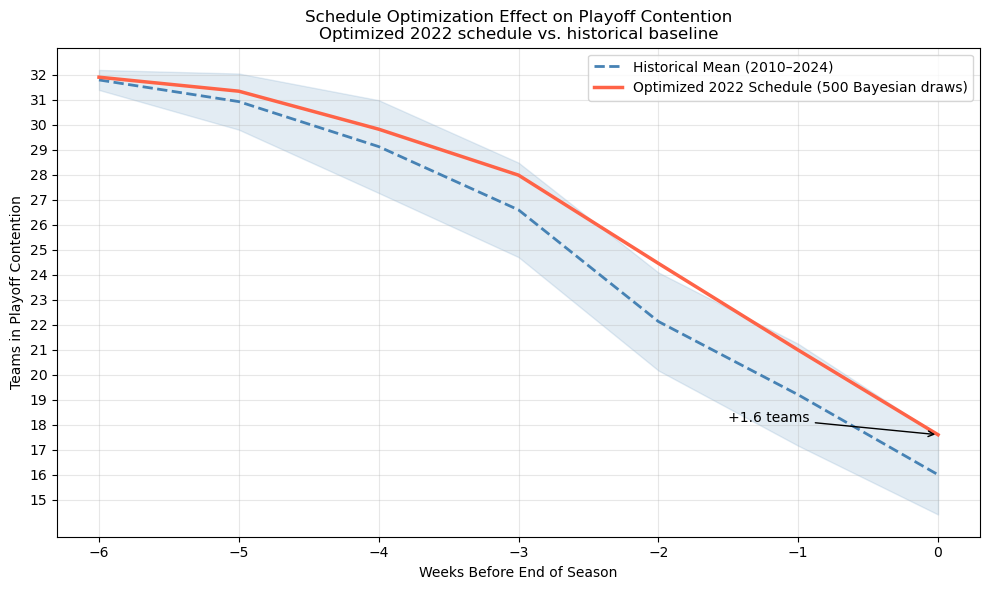

In [15]:
# Load historical baseline from Notebook A
mean_curve = np.load('../historical_mean_curve.npy')
std_curve  = np.load('../historical_std_curve.npy')

fig, ax = plt.subplots(figsize=(10, 6))
x = list(range(-6, 1))
y = list(range(15, 33))

# Historical mean ± std (background context)
ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                alpha=0.15, color='steelblue')
ax.plot(x, mean_curve, 'steelblue', linewidth=2,
        linestyle='--', label='Historical Mean (2010–2024)')

# Simulated optimized schedule mean
ax.plot(x, contention_mean, 'tomato', linewidth=2.5,
        label='Optimized 2022 Schedule (500 Bayesian draws)')

# Annotate lift at final week
lift = contention_mean[-1] - mean_curve[-1]
ax.annotate(f'+{lift:.1f} teams', xy=(0, contention_mean[-1]),
            xytext=(-1.5, contention_mean[-1] + 0.5),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

ax.set_xlabel('Weeks Before End of Season')
ax.set_ylabel('Teams in Playoff Contention')
ax.set_title('Schedule Optimization Effect on Playoff Contention\n'
             'Optimized 2022 schedule vs. historical baseline')
ax.legend()
ax.set_xticks(x)
ax.set_yticks(y)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

The optimized 2021 schedule demonstrably shifts the contention curve upward relative to the historical mean. Key takeaways:

1. **Measurable lift in contention over final six weeks:** The annotation on the final week of the graph quantifies a 1.6 average team contention improvement in the final week, but over the final six weeks this value baloons to ~8.5 teams/franchises invested in games above historical averages. This is a meaningful improvement and certainly drives excitement, ratings, and eventually advertising dollars for the NFL.  

2. **Practicality:** Of course, previous standard deviation analysis shows that any single draw of a season can yeild a range of possible contention results. Still the environment mean demonstrates that this schedule construction on average keeps more franchises in playoff contention longer into the season. If a strategy such as this was deployed each nfl season, more at-bats will bring average playoff contention higher as time goes on. 

3. **Practicality Continued:** The optimized schedule in question is made with more constraint flexability than what actually exists in the real world scheduiling problem. Prior to obtaining real scheduling constraints and TV viewership data, this analysis was intended to show what was theoretically possible with two-stage stochastic Integer Programming. In reality, playoff contention is just a proxy of TV viewership data, but we demonstrate that playoff contention can be manipulated with optimization, and could be incorporated in future schedule optimization workflows by using "# of contending teams" as a feature in the viewership model. 

4. **Connection to viewership:** If the central hypothesis holds: contention --> engagement --> ratings, then the lift shown here represents the upper bound of what schedule optimization can contribute to TV viewership. In reality, contention is just one factor among many that contribute to tv ratings. Several companion notebooks exist in the Machine Learning folder of this repository  (see `MLP_tv_ratings.ipynb`, `LightGBM_tv_Ratings.ipynb` and `LinearModel_raw_target_tv_ratings.ipynb` for a more complete analysis of what drives TV ratings in the NFL).




